In [1]:
!pip install opendatasets

In [2]:
import opendatasets as od
od.download('https://www.kaggle.com/datasets/aayush9753/image-colorization-dataset')

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: sihamkalach
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/aayush9753/image-colorization-dataset


In [4]:

import os
import numpy as np
import cv2
from tensorflow.keras.utils import img_to_array

IMG_SIZE = 128

def load_images(folder, color_mode='grayscale'):
    images = []
    for filename in sorted(os.listdir(folder)):
        path = os.path.join(folder, filename)
        if color_mode == 'grayscale':
            img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        else:
            img = cv2.imread(path)  # BGR
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img.astype('float32') / 255.0
        images.append(img)
    return np.array(images)

# Load data
X_train_gray = load_images('/content/image-colorization-dataset/data/train_black', 'grayscale').reshape(-1, IMG_SIZE, IMG_SIZE, 1)
X_train_color = load_images('/content/image-colorization-dataset/data/train_color', 'rgb')

X_test_gray = load_images('/content/image-colorization-dataset/data/test_black', 'grayscale').reshape(-1, IMG_SIZE, IMG_SIZE, 1)
X_test_color = load_images('/content/image-colorization-dataset/data/test_color', 'rgb')

In [5]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D

def build_cae():
    input_img = Input(shape=(IMG_SIZE, IMG_SIZE, 1))

    # Encoder
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = MaxPooling2D((2, 2), padding='same')(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2), padding='same')(x)

    # Decoder
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)

    output = Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)  # 3 channels for color

    return Model(input_img, output)

model = build_cae()
model.compile(optimizer='adam', loss='mse')
model.summary()




Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,075 (293.26 KB)

 Trainable params: 75,075 (293.26 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.fit(
    X_train_gray, X_train_color,
    validation_data=(X_test_gray, X_test_color),
    epochs=10,
    batch_size=16
)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 395s 1s/step - loss: 0.0179 - val_loss: 0.0133
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 397s 1s/step - loss: 0.0133 - val_loss: 0.0128
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 444s 1s/step - loss: 0.0128 - val_loss: 0.0119
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 441s 1s/step - loss: 0.0121 - val_loss: 0.0116
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 398s 1s/step - loss: 0.0120 - val_loss: 0.0113
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 433s 1s/step - loss: 0.0116 - val_loss: 0.0111
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 451s 1s/step - loss: 0.0116 - val_loss: 0.0110
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 441s 1s/step - loss: 0.0111 - val_loss: 0.0108
Epoch 9/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 401s 1s/step - loss: 0.0109 - val_loss: 0.0106
Epoch 10/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 438s 1s/step - loss: 0.0105 - val_loss: 0.0105


24/24 ━━━━━━━━━━━━━━━━━━━━ 15s 621ms/step


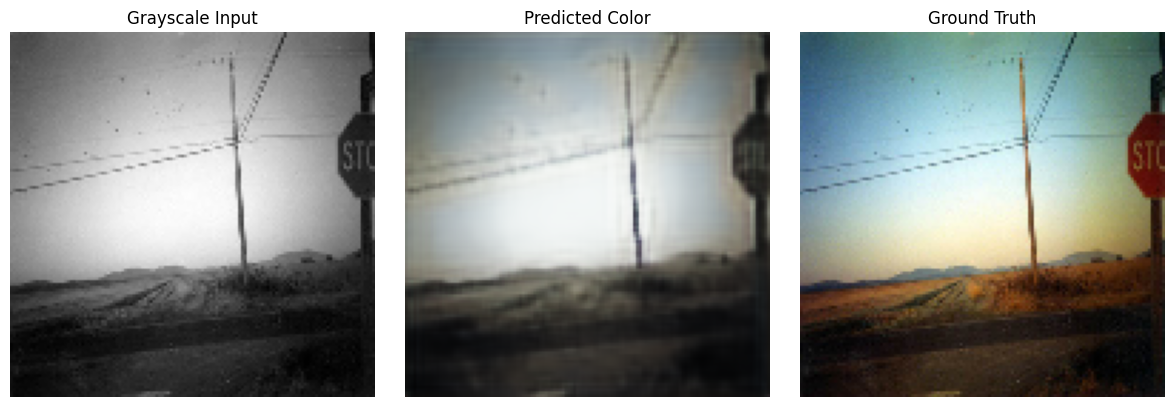

In [8]:
import matplotlib.pyplot as plt

preds = model.predict(X_test_gray)

def show_images(gray, predicted, original, index):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    axes[0].imshow(gray[index].squeeze(), cmap='gray')
    axes[0].set_title("Grayscale Input")

    axes[1].imshow(predicted[index])
    axes[1].set_title("Predicted Color")

    axes[2].imshow(original[index])
    axes[2].set_title("Ground Truth")

    for ax in axes:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# Show the first test image result
show_images(X_test_gray, preds, X_test_color, index=0)